# Equity Momentum Backtest

**Systematic Investment Strategy | Python**
**June–August 2026**

### Objective

This project tests whether a simple systematic momentum strategy can outperform the S&P 500 over the selected backtesting period.

The strategy ranks 10 large-cap U.S. equities according to their trailing 252-trading-day returns, invests equally in the three highest-ranked securities, and rebalances the portfolio monthly.

Performance is evaluated against SPY using cumulative return, annualized return, volatility, Sharpe ratio, and maximum drawdown.


## 1. Strategy

The strategy follows a simple momentum-based selection process:

1. Select a universe of 10 large-cap U.S. equities.
2. Calculate each stock's trailing 252-trading-day return.
3. Rank stocks from highest to lowest momentum.
4. Select the three highest-ranked securities.
5. Allocate one-third of the portfolio to each selected security.
6. Rebalance monthly.
7. Compare portfolio performance with SPY.

### Portfolio Selection

| Parameter          | Rule                            |
| ------------------ | ------------------------------- |
| Stock universe     | 10 large-cap U.S. equities      |
| Momentum measure   | Trailing 252-trading-day return |
| Number of holdings | 3                               |
| Weighting          | Equal-weighted                  |
| Rebalancing        | Monthly                         |
| Benchmark          | SPY                             |


In [ ]:
!pip install yfinance

## 2. Data

Historical adjusted closing prices were obtained using Yahoo Finance
through the yfinance Python library.

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
stocks = [
    "AAPL",
    "MSFT",
    "NVDA",
    "AMZN",
    "GOOGL",
    "META",
    "AVGO",
    "JPM",
    "WMT",
    "COST"
]

benchmark = "SPY"

In [ ]:
all_tickers = stocks + [benchmark]

prices = yf.download(
    all_tickers,
    start="2025-01-01",
    end="2026-09-01",
    auto_adjust=True
)["Close"]

prices.head()

[*********************100%***********************]  11 of 11 completed


Ticker,AAPL,AMZN,AVGO,COST,GOOGL,JPM,META,MSFT,NVDA,SPY,WMT
Date,,,,,,,,,,,
2025-01-02,242.093155,220.220001,229.058731,901.109924,188.324631,231.734146,596.292664,412.895325,137.949356,574.799438,88.582573
2025-01-03,241.606659,224.190002,229.621567,907.815308,190.670898,234.901184,601.656189,417.600616,144.093307,581.986450,89.350304
2025-01-06,243.234848,227.610001,233.432953,913.886597,195.721237,233.755951,627.100525,422.039429,149.040390,585.339111,89.990051
2025-01-07,240.464935,222.110001,225.760773,912.559448,194.349304,236.007599,614.850891,416.633850,139.774597,578.722412,89.379814
2025-01-08,240.951401,222.130005,226.422348,918.502075,192.818283,235.968796,607.716248,418.794159,139.744690,579.567871,90.354240


### Momentum Calculation

Momentum is measured using each stock's trailing 252-trading-day return, approximately representing one year of trading history.

A higher value indicates stronger historical price performance relative to the other securities in the investment universe.


In [ ]:
momentum = prices[stocks].pct_change(252)

momentum.tail()

Ticker,AAPL,MSFT,NVDA,AMZN,GOOGL,META,AVGO,JPM,WMT,COST
Date,,,,,,,,,,
2026-08-25,0.365669,-0.022622,0.198571,0.140797,0.688339,-0.242281,0.222292,0.227092,0.097462,0.007377
2026-08-26,0.384962,-0.007548,0.167562,0.141879,0.645046,-0.232672,0.217400,0.232011,0.095227,0.021367
2026-08-27,0.376922,0.014293,0.255893,0.120458,0.649232,-0.240191,0.255872,0.209085,0.077502,-0.001303
2026-08-28,0.392169,0.021737,0.199558,0.162840,0.675240,-0.224070,0.237276,0.217795,0.081994,0.001544
2026-08-31,0.367477,0.003579,0.227030,0.121632,0.608005,-0.235510,0.208662,0.205138,0.100333,0.004696


In [ ]:
momentum.loc["2026-08-31"].sort_values(ascending=False)

,2026-08-31
Ticker,
GOOGL,0.608005
AAPL,0.367477
NVDA,0.227030
AVGO,0.208662
JPM,0.205138
AMZN,0.121632
WMT,0.100333
COST,0.004696
MSFT,0.003579


In [ ]:
monthly_momentum = momentum.resample("ME").last()

top_3 = monthly_momentum.apply(
    lambda row: row.nlargest(3).index.tolist(),
    axis=1
)

top_3

,0
Date,
2025-01-31,"[AAPL, MSFT, NVDA]"
2025-02-28,"[AAPL, MSFT, NVDA]"
2025-03-31,"[AAPL, MSFT, NVDA]"
2025-04-30,"[AAPL, MSFT, NVDA]"
2025-05-31,"[AAPL, MSFT, NVDA]"
2025-06-30,"[AAPL, MSFT, NVDA]"
2025-07-31,"[AAPL, MSFT, NVDA]"
2025-08-31,"[AAPL, MSFT, NVDA]"
2025-09-30,"[AAPL, MSFT, NVDA]"


In [ ]:
def max_drawdown(price_series):
    running_max = price_series.cummax()
    drawdown = price_series / running_max - 1
    return drawdown.min()

In [ ]:
for stock in stocks:
    print(stock, max_drawdown(prices[stock]))

AAPL -0.30222579131963756
MSFT -0.34498397568158834
NVDA -0.3688103345877982
AMZN -0.3087663843187606
GOOGL -0.29805858030221777
META -0.34150812344502446
AVGO -0.4003569246881835
JPM -0.24423926616996172
WMT -0.23341506413434532
COST -0.20742503432058956


In [ ]:
daily_returns = prices[stocks].pct_change()

In [ ]:
weights = pd.DataFrame(
    0.0,
    index=prices.index,
    columns=stocks
)

for date in monthly_momentum.index:
    selected = top_3.loc[date]

    for stock in selected:
        weights.loc[date, stock] = 1 / 3

weights = weights.ffill()

In [ ]:
portfolio_returns = (daily_returns * weights.shift(1)).sum(axis=1)

In [ ]:
portfolio_growth = (1 + portfolio_returns).cumprod()

In [ ]:
spy_returns = prices["SPY"].pct_change()

spy_growth = (1 + spy_returns).cumprod()

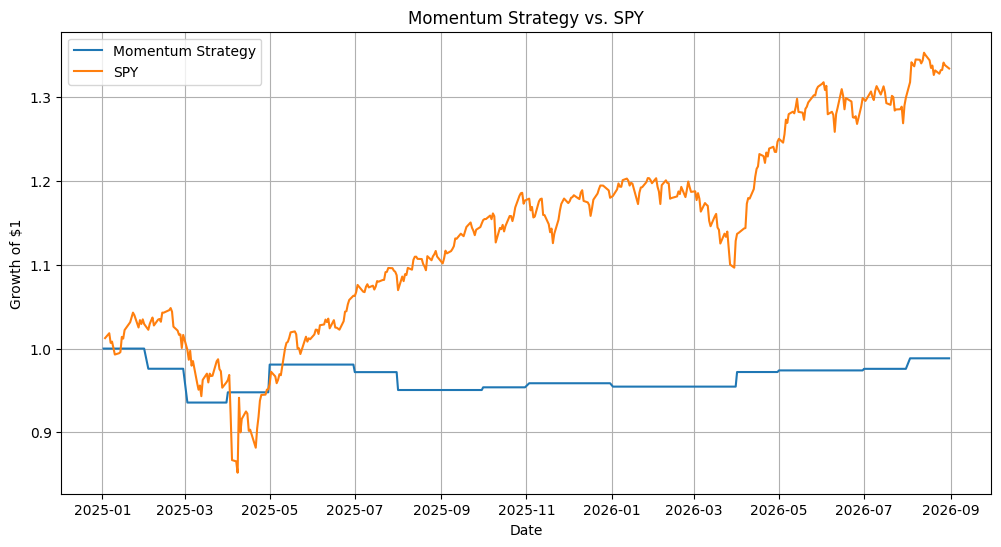

In [ ]:
plt.figure(figsize=(12, 6))

plt.plot(portfolio_growth, label="Momentum Strategy")
plt.plot(spy_growth, label="SPY")

plt.title("Momentum Strategy vs. SPY")
plt.xlabel("Date")
plt.ylabel("Growth of $1")

plt.legend()
plt.grid(True)

plt.show()

In [ ]:
strategy_cumulative_return = portfolio_growth.iloc[-1] - 1
spy_cumulative_return = spy_growth.iloc[-1] - 1

print("Strategy:", strategy_cumulative_return)
print("SPY:", spy_cumulative_return)

Strategy: -0.01162040549250487
SPY: 0.3344654438528043


In [ ]:
days = (portfolio_returns.index[-1] - portfolio_returns.index[0]).days

annualized_return = (
    (1 + strategy_cumulative_return) ** (365 / days)
) - 1

print("Annualized return:", annualized_return)

Annualized return: -0.007015349790511993


## 6. Risk Analysis

Returns alone do not fully describe portfolio performance. The strategy was therefore evaluated using volatility, Sharpe ratio, and maximum drawdown.

**Volatility** measures the variability of daily portfolio returns.

**Sharpe ratio** measures risk-adjusted return by comparing portfolio returns with their volatility.

**Maximum drawdown** measures the largest decline from a previous portfolio peak during the backtesting period.

These metrics provide additional context for evaluating the strategy's performance relative to SPY.


In [ ]:
annualized_volatility = portfolio_returns.std() * np.sqrt(252)

print("Annualized volatility:", annualized_volatility)

Annualized volatility: 0.053665587381664964


In [ ]:
sharpe_ratio = (
    portfolio_returns.mean() /
    portfolio_returns.std()
) * np.sqrt(252)

print("Sharpe ratio:", sharpe_ratio)

Sharpe ratio: -0.1031174919015577


In [ ]:
strategy_max_drawdown = max_drawdown(portfolio_growth)

print("Maximum drawdown:", strategy_max_drawdown)

Maximum drawdown: -0.06444785625120775


In [ ]:
results = pd.DataFrame({
    "Metric": [
        "Cumulative Return",
        "Annualized Return",
        "Annualized Volatility",
        "Sharpe Ratio",
        "Maximum Drawdown"
    ],
    "Momentum Strategy": [
        strategy_cumulative_return,
        annualized_return,
        annualized_volatility,
        sharpe_ratio,
        strategy_max_drawdown
    ]
})

results["SPY"] = [
    spy_cumulative_return,
    ((1 + spy_cumulative_return) ** (365 / days)) - 1,
    spy_returns.std() * np.sqrt(252),
    (spy_returns.mean() / spy_returns.std()) * np.sqrt(252),
    max_drawdown(spy_growth)
]

results

,Metric,Momentum Strategy,SPY
0,Cumulative Return,-0.011620,0.334465
1,Annualized Return,-0.007015,0.189800
2,Annualized Volatility,0.053666,0.173344
3,Sharpe Ratio,-0.103117,1.096807
4,Maximum Drawdown,-0.064448,-0.187552


## 7. Conclusion

The backtest evaluates whether a simple one-year momentum signal can generate competitive performance relative to SPY over the selected testing period.

The strategy's results should be interpreted cautiously because the backtesting window is relatively short. Historical backtest performance does not guarantee future results, and the strategy may be sensitive to the selected stocks, time period, transaction costs, and other assumptions.

Future iterations could expand the stock universe, extend the testing period, incorporate transaction costs, and evaluate additional momentum and risk-management techniques.
